# Knee Osteoarthritis Classification - Multi-Model Training
## Using VGG16, VGG19, ResNet101, MobileNetV2, InceptionV3, and DenseNet121

## 1. Setup and Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from tqdm import tqdm
import pandas as pd
import time
import os


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


## 2. Setup for Kaggle
### Note: Upload your dataset to Kaggle and update the paths below

In [3]:
import os
print("Running on Kaggle")
print(f"Available CPUs: {os.cpu_count()}")
print(f"GPU Available: {torch.cuda.is_available()}")


if os.path.exists('/kaggle/input'):
    print("\nAvailable datasets in /kaggle/input:")
    for item in os.listdir('/kaggle/input'):
        print(f"  - {item}")

Running on Kaggle
Available CPUs: 4
GPU Available: True

Available datasets in /kaggle/input:
  - knee-dataset


## 3. Hyperparameters and Data Paths

In [4]:
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
NUM_EPOCHS = 50
NUM_CLASSES = 5
IMG_SIZE = 224
IMG_SIZE_INCEPTION = 299


DATASET_NAME = 'knee-dataset'

TRAIN_DIR = f'/kaggle/input/{DATASET_NAME}/filtered_Train_dataset'
VAL_DIR = f'/kaggle/input/{DATASET_NAME}/val'
TEST_DIR = f'/kaggle/input/{DATASET_NAME}/test'


print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Image Size (standard): {IMG_SIZE}x{IMG_SIZE}")
print(f"Image Size (InceptionV3): {IMG_SIZE_INCEPTION}x{IMG_SIZE_INCEPTION}")
print(f"\nData paths:")
print(f"  Train: {TRAIN_DIR}")
print(f"  Val: {VAL_DIR}")
print(f"  Test: {TEST_DIR}")

Batch Size: 32
Learning Rate: 0.0001
Epochs: 50
Image Size (standard): 224x224
Image Size (InceptionV3): 299x299

Data paths:
  Train: /kaggle/input/knee-dataset/filtered_Train_dataset
  Val: /kaggle/input/knee-dataset/val
  Test: /kaggle/input/knee-dataset/test


## 4. Data Transforms and Augmentation

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])


val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])


train_transforms_inception = transforms.Compose([
    transforms.Resize((IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

val_test_transforms_inception = transforms.Compose([
    transforms.Resize((IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

print("✓ Transforms configured")

✓ Transforms configured


## 5. Load Datasets and Create Data Loaders

In [6]:
print("\n" + "="*70)
print("LOADING DATASETS")
print("="*70)


train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transforms)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f'Train samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Classes: {train_dataset.classes}')
print(f'Class distribution:')
for i, class_name in enumerate(train_dataset.classes):
    count = sum([1 for _, label in train_dataset if label == i])
    print(f'  {class_name}: {count} images')


LOADING DATASETS
Train samples: 5778
Validation samples: 826
Test samples: 1656
Classes: ['0', '1', '2', '3', '4']
Class distribution:
  0: 2286 images
  1: 1046 images
  2: 1516 images
  3: 757 images
  4: 173 images


## 6. Model Definitions

In [7]:
def create_vgg16(num_classes=5, pretrained=True):
    model = models.vgg16(pretrained=pretrained)
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

def create_vgg19(num_classes=5, pretrained=True):
    model = models.vgg19(pretrained=pretrained)
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

def create_resnet101(num_classes=5, pretrained=True):
    model = models.resnet101(pretrained=pretrained)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

def create_mobilenetv2(num_classes=5, pretrained=True):
    model = models.mobilenet_v2(pretrained=pretrained)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

def create_densenet121(num_classes=5, pretrained=True):
    model = models.densenet121(pretrained=pretrained)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

def create_inception_resnet_v2(num_classes=5, pretrained=True):
    if pretrained:
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=False)
    else:
        model = models.inception_v3(aux_logits=False)

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model


MODEL_DICT = {
    'VGG16': create_vgg16,
    'VGG19': create_vgg19,
    'ResNet101': create_resnet101,
    'MobileNetV2': create_mobilenetv2,
    'InceptionV3': create_inception_resnet_v2,
    'DenseNet121': create_densenet121
}

print("✓ Model definitions loaded")
print(f"Available models: {list(MODEL_DICT.keys())}")

✓ Model definitions loaded
Available models: ['VGG16', 'VGG19', 'ResNet101', 'MobileNetV2', 'InceptionV3', 'DenseNet121']


## 7. Training and Validation Functions

In [8]:
def train_epoch(model, loader, criterion, optimizer, device, model_name=''):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f'Training {model_name}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device, model_name=''):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f'Validating {model_name}'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def test_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Testing'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

print("✓ Training and validation functions defined")

✓ Training and validation functions defined


## 8. Helper Function for Training Individual Models

In [9]:
results_summary = []

def train_single_model(model_name, model_fn, train_loader_to_use, val_loader_to_use, test_loader_to_use):
    print(f"\n{'='*70}")
    print(f"MODEL: {model_name}")
    print(f"{'='*70}")

    start_time = time.time()


    model = model_fn(num_classes=NUM_CLASSES, pretrained=True)
    model = model.to(device)


    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters: {total_params:,}')
    print(f'Trainable parameters: {trainable_params:,}')


    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


    best_val_acc = 0.0
    train_history = {'loss': [], 'acc': []}
    val_history = {'loss': [], 'acc': []}

    for epoch in range(NUM_EPOCHS):
        print(f'\nEpoch [{epoch+1}/{NUM_EPOCHS}]')

        train_loss, train_acc = train_epoch(model, train_loader_to_use, criterion, optimizer, device, model_name)
        val_loss, val_acc = validate(model, val_loader_to_use, criterion, device, model_name)

        train_history['loss'].append(train_loss)
        train_history['acc'].append(train_acc)
        val_history['loss'].append(val_loss)
        val_history['acc'].append(val_acc)

        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

        scheduler.step(val_acc)


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower()}.pth')
            print(f'✓ Best model saved! Val Acc: {best_val_acc:.2f}%')


    print(f'\nTesting {model_name}...')
    model.load_state_dict(torch.load(f'best_{model_name.lower()}.pth'))
    test_labels, test_preds = test_model(model, test_loader_to_use, device)
    test_acc = accuracy_score(test_labels, test_preds) * 100

    training_time = time.time() - start_time


    class_names = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
    print(f'\n{model_name} Classification Report:')
    print(classification_report(test_labels, test_preds, target_names=class_names))


    result = {
        'Model': model_name,
        'Parameters': total_params,
        'Best Val Acc': best_val_acc,
        'Test Acc': test_acc,
        'Training Time (min)': training_time / 60
    }
    results_summary.append(result)


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(val_history['loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(train_history['acc'], label='Train Acc', linewidth=2)
    axes[1].plot(val_history['acc'], label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_training_history.png', dpi=300)
    plt.show()
    plt.close()


    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix\nTest Accuracy: {test_acc:.2f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_confusion_matrix.png', dpi=300)
    plt.show()
    plt.close()

    print(f'\n{model_name} completed in {training_time/60:.2f} minutes')
    print(f'Test Accuracy: {test_acc:.2f}%')


    del model
    torch.cuda.empty_cache()

    return result

print("✓ Helper function defined")

✓ Helper function defined


## 9. Train VGG16


MODEL: VGG16


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 206MB/s]  


Total parameters: 136,360,773
Trainable parameters: 136,360,773

Epoch [1/50]


Validating VGG16: 100%|██████████| 26/26 [00:06<00:00,  4.09it/s]


Train Loss: 1.3518 | Train Acc: 41.48%
Val Loss: 1.2507 | Val Acc: 44.07%
✓ Best model saved! Val Acc: 44.07%

Epoch [2/50]


...

Train Loss: 0.0851 | Train Acc: 97.04%
Val Loss: 2.1500 | Val Acc: 62.83%

Epoch [50/50]


Validating VGG16: 100%|██████████| 26/26 [00:05<00:00,  4.49it/s]


Train Loss: 0.0835 | Train Acc: 97.02%
Val Loss: 2.1349 | Val Acc: 62.83%

Testing VGG16...


Testing: 100%|██████████| 52/52 [00:11<00:00,  4.53it/s]



VGG16 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.68      0.93      0.79       639
     Grade 1       0.41      0.09      0.14       296
     Grade 2       0.67      0.70      0.68       447
     Grade 3       0.84      0.73      0.78       223
     Grade 4       0.75      0.92      0.82        51

    accuracy                           0.69      1656
   macro avg       0.67      0.67      0.64      1656
weighted avg       0.65      0.69      0.64      1656



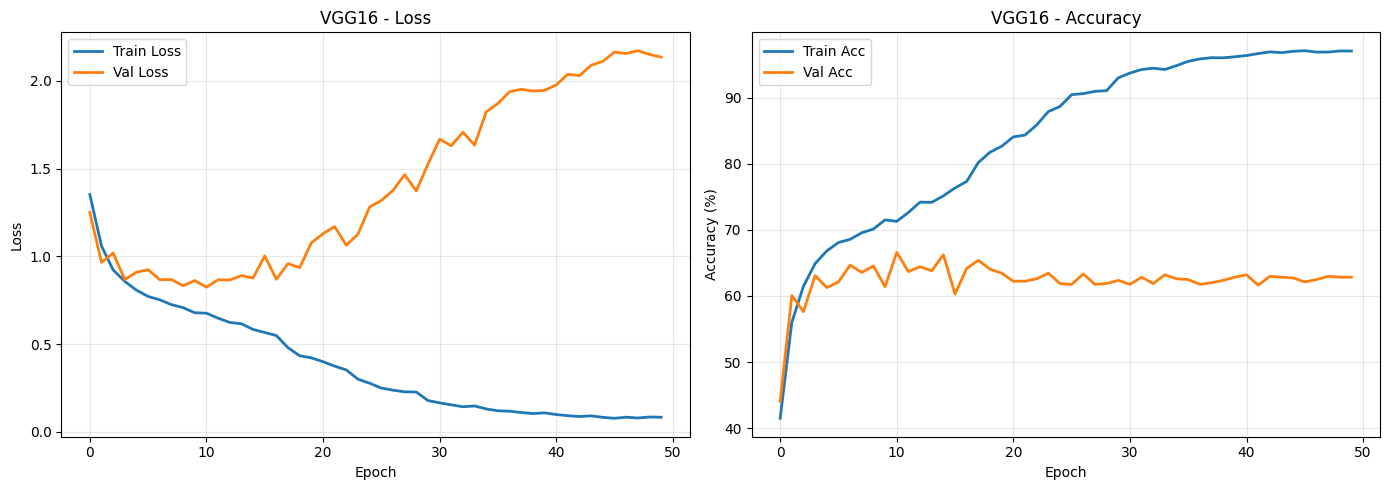

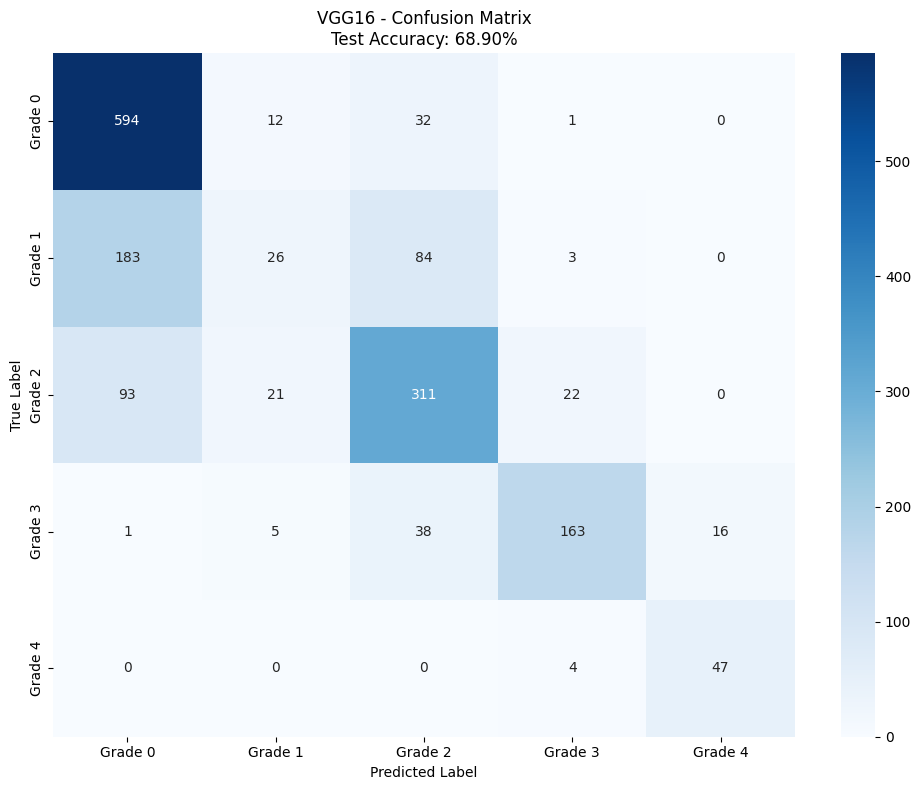


VGG16 completed in 96.62 minutes
Test Accuracy: 68.90%


{'Model': 'VGG16',
 'Parameters': 136360773,
 'Best Val Acc': 66.5859564164649,
 'Test Acc': 68.90096618357488,
 'Training Time (min)': 96.62313090165456}

In [10]:
train_single_model('VGG16', create_vgg16, train_loader, val_loader, test_loader)

## 10. Train VGG19


MODEL: VGG19


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:02<00:00, 220MB/s]  


Total parameters: 141,670,469
Trainable parameters: 141,670,469

Epoch [1/50]


Validating VGG19: 100%|██████████| 26/26 [00:06<00:00,  3.73it/s]


Train Loss: 1.3730 | Train Acc: 39.98%
Val Loss: 1.3397 | Val Acc: 43.34%
✓ Best model saved! Val Acc: 43.34%

Epoch [2/50]


...

Train Loss: 0.0897 | Train Acc: 96.75%
Val Loss: 2.2587 | Val Acc: 62.59%

Epoch [50/50]


Validating VGG19: 100%|██████████| 26/26 [00:07<00:00,  3.71it/s]


Train Loss: 0.0785 | Train Acc: 97.18%
Val Loss: 2.2890 | Val Acc: 62.23%

Testing VGG19...


Testing: 100%|██████████| 52/52 [00:13<00:00,  3.78it/s]



VGG19 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.73      0.88      0.79       639
     Grade 1       0.32      0.29      0.30       296
     Grade 2       0.71      0.56      0.63       447
     Grade 3       0.84      0.81      0.82       223
     Grade 4       0.85      0.80      0.83        51

    accuracy                           0.68      1656
   macro avg       0.69      0.67      0.68      1656
weighted avg       0.67      0.68      0.67      1656



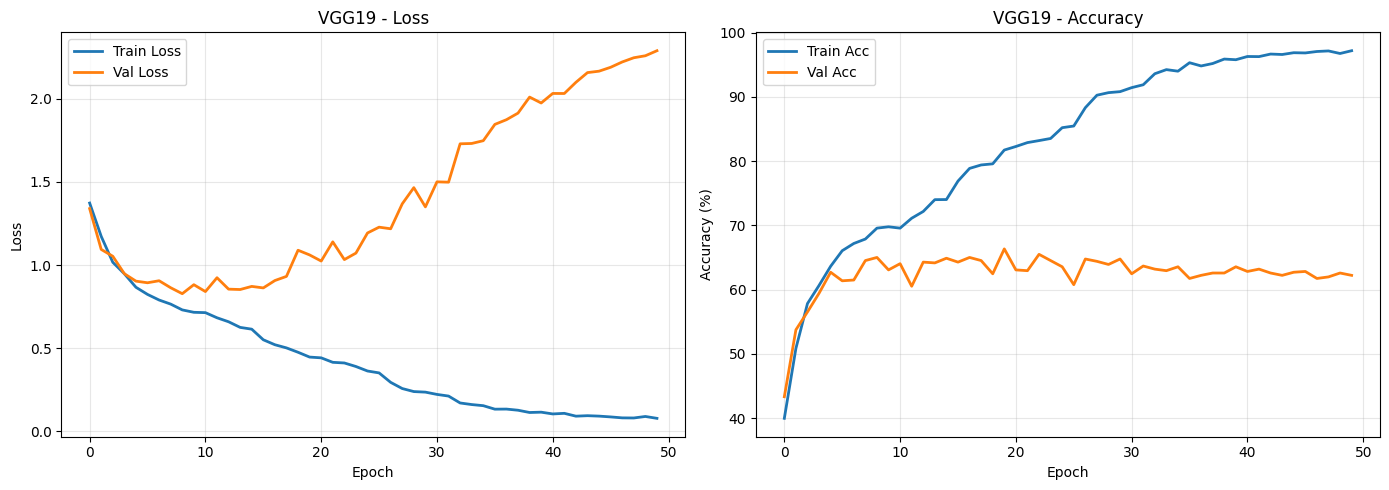

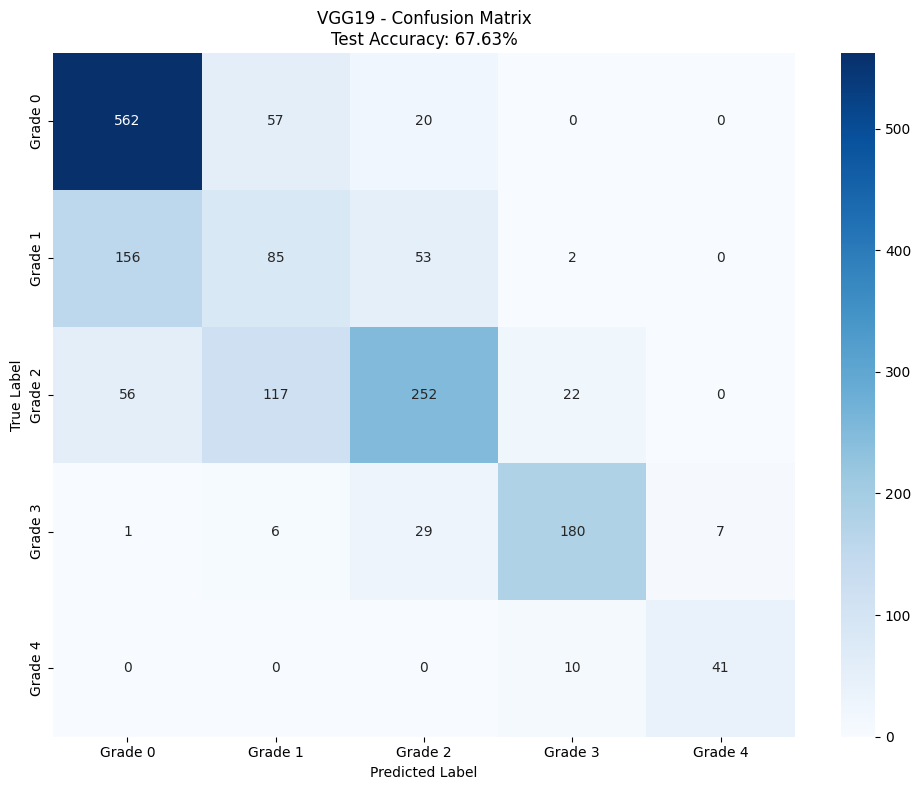


VGG19 completed in 113.09 minutes
Test Accuracy: 67.63%


{'Model': 'VGG19',
 'Parameters': 141670469,
 'Best Val Acc': 66.34382566585957,
 'Test Acc': 67.6328502415459,
 'Training Time (min)': 113.09345316092173}

In [11]:
train_single_model('VGG19', create_vgg19, train_loader, val_loader, test_loader)

## 11. Train ResNet101


MODEL: ResNet101


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 190MB/s] 


Total parameters: 43,551,813
Trainable parameters: 43,551,813

Epoch [1/50]


Validating ResNet101: 100%|██████████| 26/26 [00:05<00:00,  4.67it/s]


Train Loss: 1.1709 | Train Acc: 51.11%
Val Loss: 1.1406 | Val Acc: 51.57%
✓ Best model saved! Val Acc: 51.57%

Epoch [2/50]


...

Train Loss: 0.0234 | Train Acc: 99.24%
Val Loss: 1.8010 | Val Acc: 62.47%

Epoch [50/50]


Validating ResNet101: 100%|██████████| 26/26 [00:05<00:00,  4.63it/s]


Train Loss: 0.0181 | Train Acc: 99.52%
Val Loss: 1.7745 | Val Acc: 62.47%

Testing ResNet101...


Testing: 100%|██████████| 52/52 [00:10<00:00,  4.80it/s]



ResNet101 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.65      0.93      0.76       639
     Grade 1       0.30      0.10      0.16       296
     Grade 2       0.72      0.49      0.59       447
     Grade 3       0.68      0.81      0.74       223
     Grade 4       0.68      0.88      0.77        51

    accuracy                           0.65      1656
   macro avg       0.61      0.64      0.60      1656
weighted avg       0.61      0.65      0.60      1656



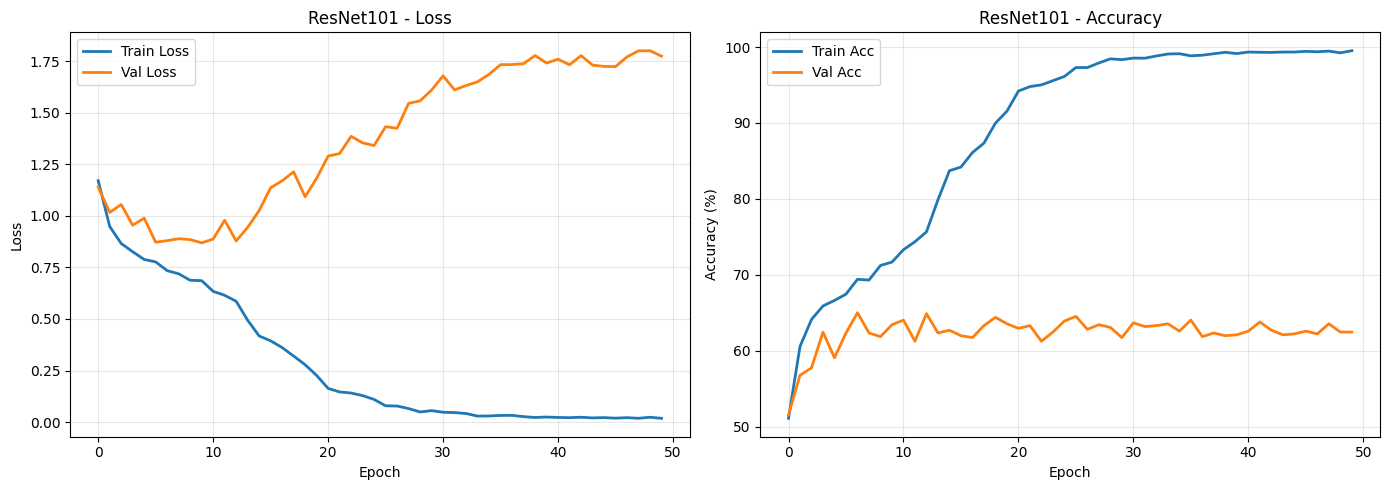

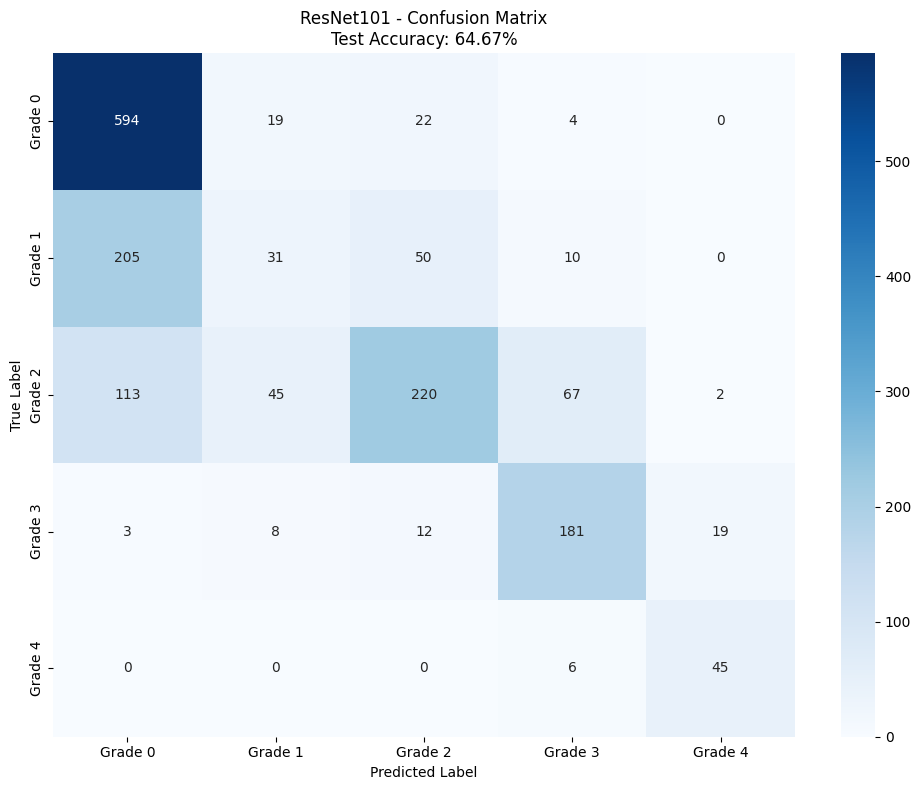


ResNet101 completed in 105.29 minutes
Test Accuracy: 64.67%


{'Model': 'ResNet101',
 'Parameters': 43551813,
 'Best Val Acc': 65.01210653753027,
 'Test Acc': 64.67391304347827,
 'Training Time (min)': 105.28848107655843}

In [12]:
train_single_model('ResNet101', create_resnet101, train_loader, val_loader, test_loader)

## 12. Train MobileNetV2

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth



MODEL: MobileNetV2


100%|██████████| 13.6M/13.6M [00:00<00:00, 123MB/s]


Total parameters: 2,882,309
Trainable parameters: 2,882,309

Epoch [1/50]


Validating MobileNetV2: 100%|██████████| 26/26 [00:01<00:00, 14.86it/s]


...

Train Loss: 0.1727 | Train Acc: 93.63%
Val Loss: 1.4473 | Val Acc: 60.65%

Epoch [50/50]


Validating MobileNetV2: 100%|██████████| 26/26 [00:01<00:00, 16.92it/s]


Train Loss: 0.1677 | Train Acc: 93.91%
Val Loss: 1.4692 | Val Acc: 60.05%

Testing MobileNetV2...


Testing: 100%|██████████| 52/52 [00:02<00:00, 18.47it/s]



MobileNetV2 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.66      0.91      0.76       639
     Grade 1       0.31      0.21      0.25       296
     Grade 2       0.67      0.53      0.59       447
     Grade 3       0.87      0.68      0.76       223
     Grade 4       0.85      0.80      0.83        51

    accuracy                           0.65      1656
   macro avg       0.67      0.63      0.64      1656
weighted avg       0.63      0.65      0.63      1656



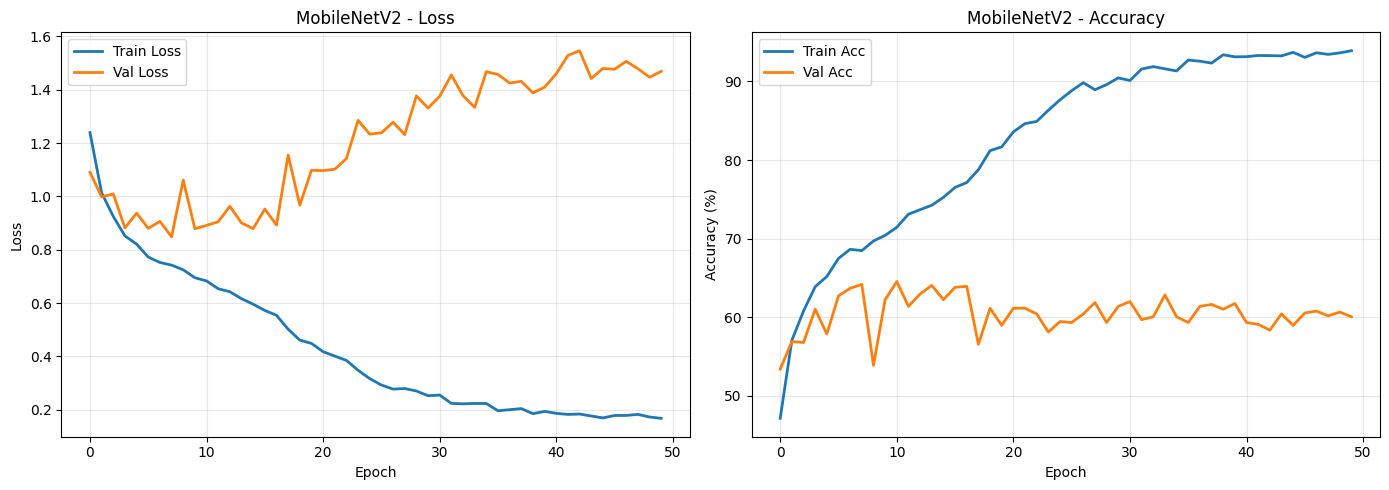

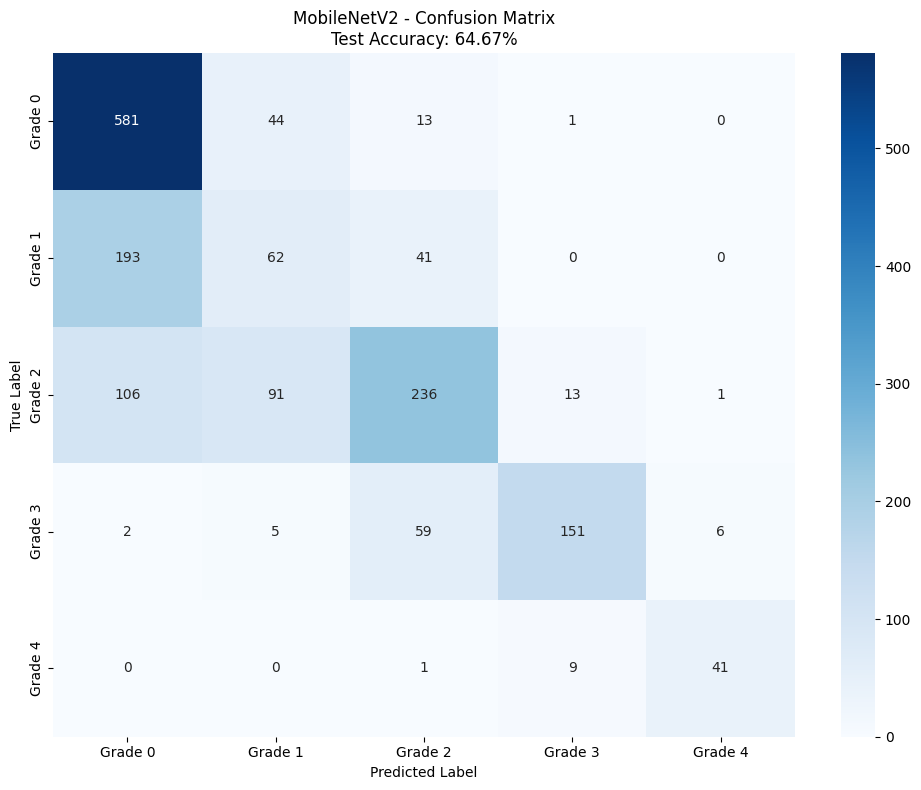


MobileNetV2 completed in 22.59 minutes
Test Accuracy: 64.67%


{'Model': 'MobileNetV2',
 'Parameters': 2882309,
 'Best Val Acc': 64.52784503631962,
 'Test Acc': 64.67391304347827,
 'Training Time (min)': 22.586316168308258}

In [13]:
train_single_model('MobileNetV2', create_mobilenetv2, train_loader, val_loader, test_loader)

## 13. Train InceptionV3 (Requires 299x299 input)

In [4]:
def create_inception_resnet_v2(num_classes=5, pretrained=True):
    if pretrained:
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)

        model.aux_logits = False
        model.AuxLogits = None
    else:
        model = models.inception_v3(aux_logits=False)

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

Creating 299x299 data loaders for InceptionV3...

MODEL: InceptionV3


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 194MB/s]  


Total parameters: 22,837,221
Trainable parameters: 22,837,221

Epoch [1/50]


Validating InceptionV3: 100%|██████████| 26/26 [00:04<00:00,  6.19it/s]


Train Loss: 1.2110 | Train Acc: 48.15%
Val Loss: 1.0821 | Val Acc: 53.87%
✓ Best model saved! Val Acc: 53.87%

Epoch [2/50]


...

Train Loss: 0.0107 | Train Acc: 99.72%
Val Loss: 1.9371 | Val Acc: 64.53%

Epoch [50/50]


Validating InceptionV3: 100%|██████████| 26/26 [00:04<00:00,  6.11it/s]


Train Loss: 0.0079 | Train Acc: 99.86%
Val Loss: 1.9539 | Val Acc: 64.04%

Testing InceptionV3...


Testing: 100%|██████████| 52/52 [00:08<00:00,  6.48it/s]



InceptionV3 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.73      0.80      0.76       639
     Grade 1       0.30      0.29      0.30       296
     Grade 2       0.68      0.61      0.64       447
     Grade 3       0.82      0.81      0.81       223
     Grade 4       0.89      0.76      0.82        51

    accuracy                           0.66      1656
   macro avg       0.68      0.66      0.67      1656
weighted avg       0.65      0.66      0.65      1656



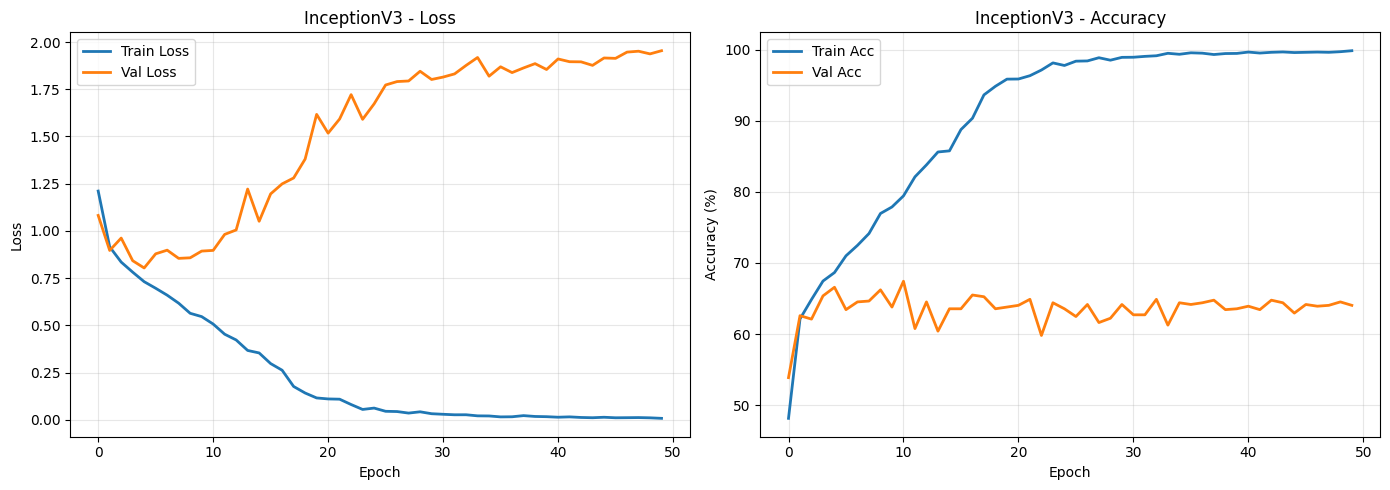

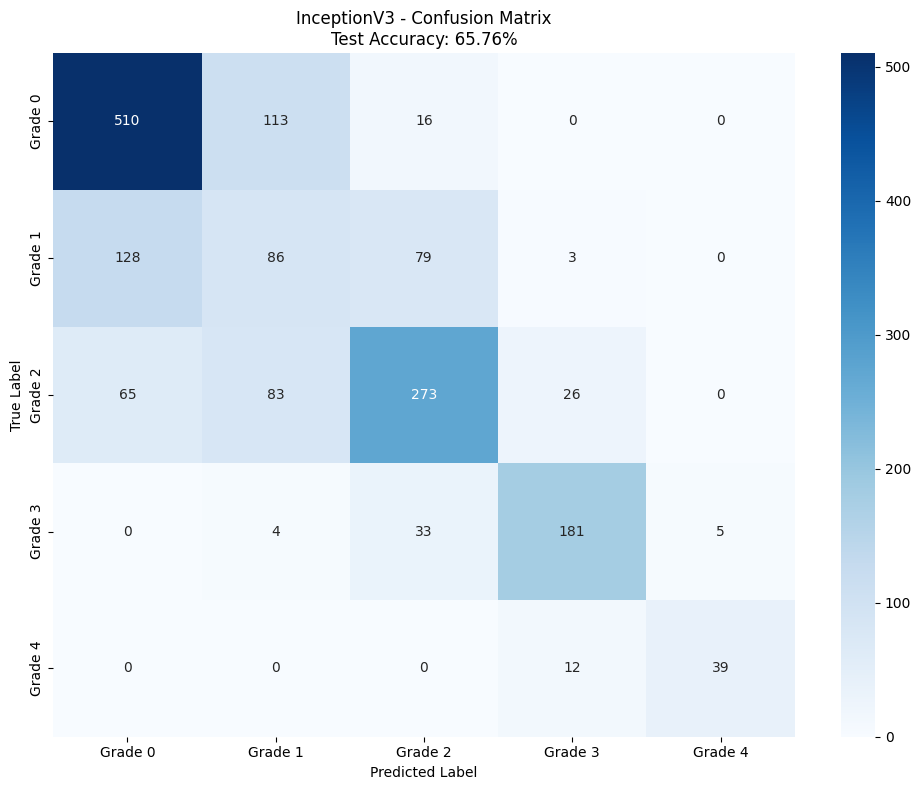


InceptionV3 completed in 74.30 minutes
Test Accuracy: 65.76%


{'Model': 'InceptionV3',
 'Parameters': 22837221,
 'Best Val Acc': 67.43341404358354,
 'Test Acc': 65.76086956521739,
 'Training Time (min)': 74.29912399848303}

In [5]:
print("Creating 299x299 data loaders for InceptionV3...")
train_dataset_inception = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms_inception)
val_dataset_inception = datasets.ImageFolder(root=VAL_DIR, transform=val_test_transforms_inception)
test_dataset_inception = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transforms_inception)

train_loader_inception = DataLoader(train_dataset_inception, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader_inception = DataLoader(val_dataset_inception, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader_inception = DataLoader(test_dataset_inception, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


train_single_model('InceptionV3', create_inception_resnet_v2, train_loader_inception, val_loader_inception, test_loader_inception)

## 14. Train DenseNet121


MODEL: DenseNet121


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 142MB/s]


Total parameters: 7,481,221
Trainable parameters: 7,481,221

Epoch [1/50]


Validating DenseNet121: 100%|██████████| 26/26 [00:03<00:00,  7.95it/s]


Train Loss: 1.2490 | Train Acc: 46.19%
Val Loss: 1.1443 | Val Acc: 51.09%
✓ Best model saved! Val Acc: 51.09%

Epoch [2/50]


...

Train Loss: 0.0200 | Train Acc: 99.41%
Val Loss: 1.7627 | Val Acc: 63.92%

Epoch [50/50]


Validating DenseNet121: 100%|██████████| 26/26 [00:03<00:00,  8.13it/s]


Train Loss: 0.0180 | Train Acc: 99.39%
Val Loss: 1.7538 | Val Acc: 64.41%

Testing DenseNet121...


Testing: 100%|██████████| 52/52 [00:06<00:00,  8.08it/s]



DenseNet121 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.73      0.80      0.77       639
     Grade 1       0.32      0.30      0.31       296
     Grade 2       0.67      0.54      0.60       447
     Grade 3       0.70      0.86      0.77       223
     Grade 4       0.84      0.80      0.82        51

    accuracy                           0.65      1656
   macro avg       0.65      0.66      0.65      1656
weighted avg       0.64      0.65      0.64      1656



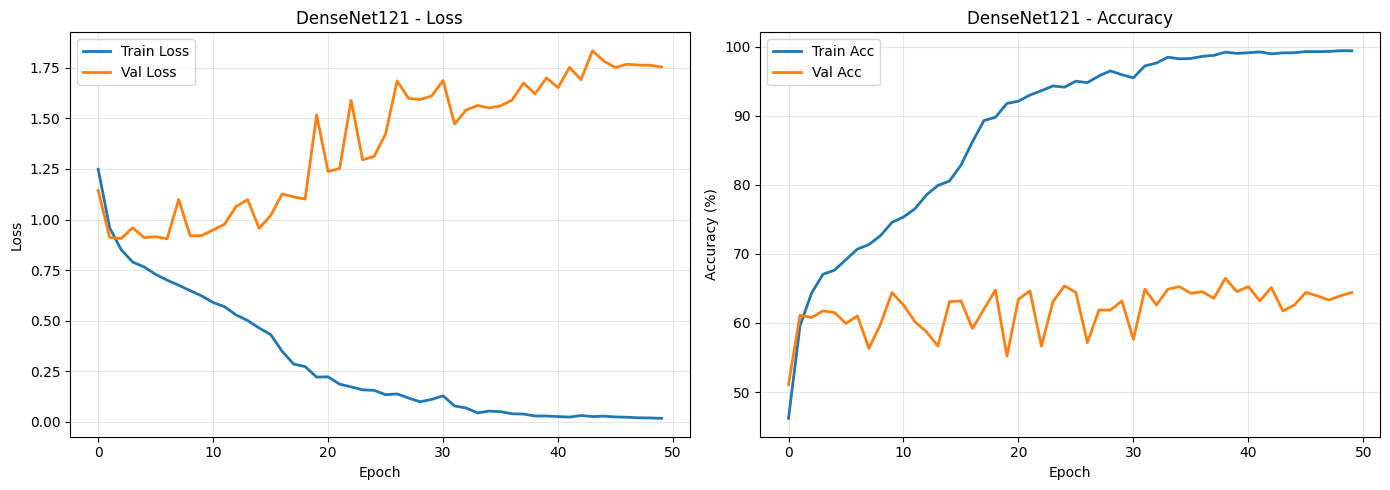

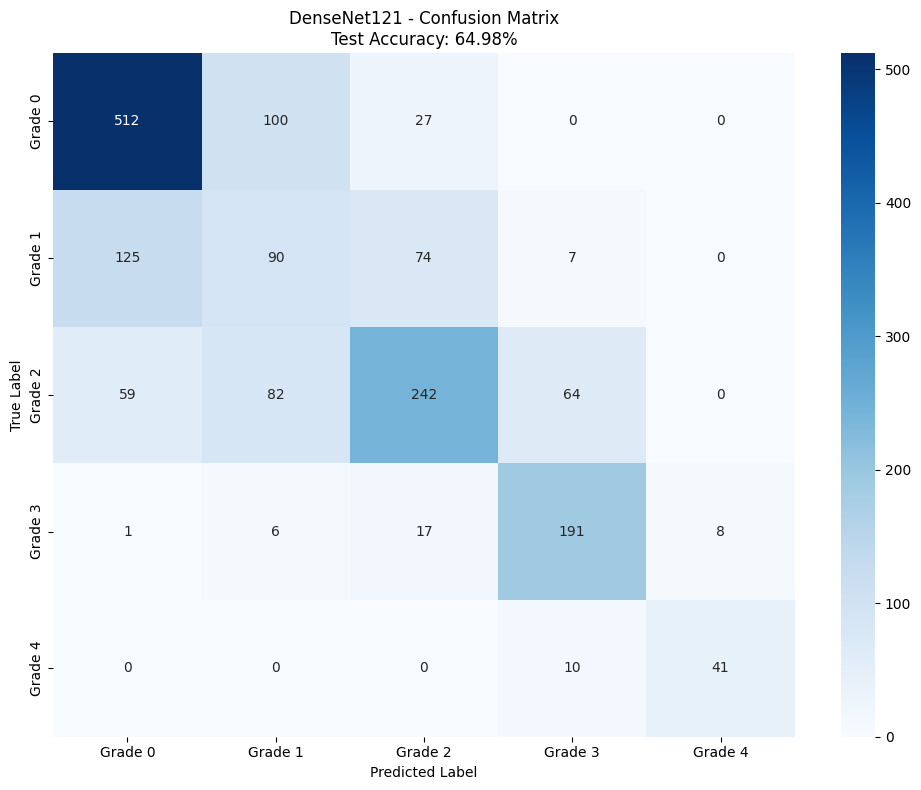


DenseNet121 completed in 53.57 minutes
Test Accuracy: 64.98%


{'Model': 'DenseNet121',
 'Parameters': 7481221,
 'Best Val Acc': 66.46489104116223,
 'Test Acc': 64.97584541062803,
 'Training Time (min)': 53.57415319283803}

In [1]:
train_single_model('DenseNet121', create_densenet121, train_loader, val_loader, test_loader)

## 15. Final Results Comparison

In [1]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values('Test Acc', ascending=False)
print("\n", results_df.to_string(index=False))


results_df.to_csv('model_comparison_results.csv', index=False)
print("\n✓ Results saved to 'model_comparison_results.csv'")


FINAL RESULTS SUMMARY

       Model  Parameters  Best Val Acc  Test Acc  Training Time (min)
      VGG16   136360773     66.585956 68.900966            96.623131
      VGG19   141670469     66.343826 67.632850           113.093453
InceptionV3    22837221     67.433414 65.760870            74.299124
DenseNet121     7481221     66.464891 64.975845            53.574153
MobileNetV2     2882309     64.527845 64.673913            22.586316
  ResNet101    43551813     65.012107 64.673913           105.288481

✓ Results saved to 'model_comparison_results.csv'


## 16. Visualization - Model Comparison

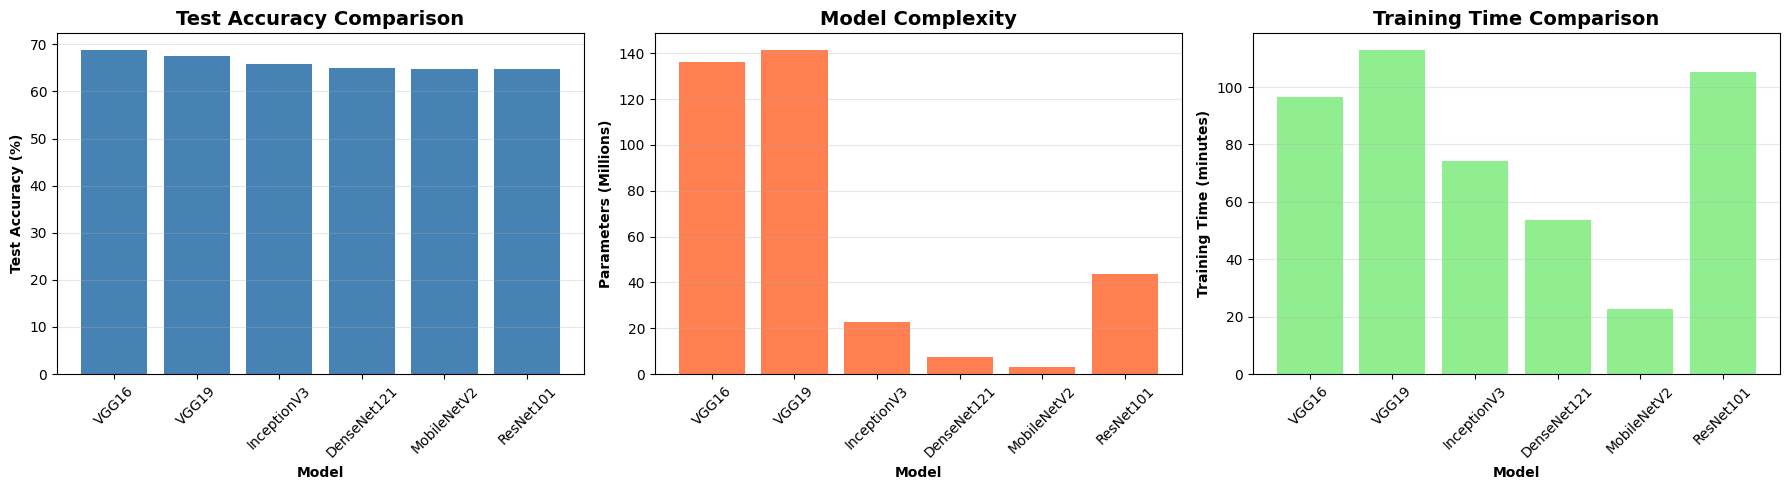


VISUALIZATION COMPLETE!

Best Model: VGG16 with 68.90% test accuracy

Files saved:
  - Individual model weights: best_*.pth
  - Training curves: *_training_history.png
  - Confusion matrices: *_confusion_matrix.png
  - Comparison results: model_comparison_results.csv
  - Comparison plots: model_comparison.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].bar(results_df['Model'], results_df['Test Acc'], color='steelblue')
axes[0].set_xlabel('Model', fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)', fontweight='bold')
axes[0].set_title('Test Accuracy Comparison', fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)


axes[1].bar(results_df['Model'], results_df['Parameters']/1e6, color='coral')
axes[1].set_xlabel('Model', fontweight='bold')
axes[1].set_ylabel('Parameters (Millions)', fontweight='bold')
axes[1].set_title('Model Complexity', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)


axes[2].bar(results_df['Model'], results_df['Training Time (min)'], color='lightgreen')
axes[2].set_xlabel('Model', fontweight='bold')
axes[2].set_ylabel('Training Time (minutes)', fontweight='bold')
axes[2].set_title('Training Time Comparison', fontweight='bold', fontsize=14)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("VISUALIZATION COMPLETE!")
print("="*70)
print(f"\nBest Model: {results_df.iloc[0]['Model']} with {results_df.iloc[0]['Test Acc']:.2f}% test accuracy")
print("\nFiles saved:")
print("  - Individual model weights: best_*.pth")
print("  - Training curves: *_training_history.png")
print("  - Confusion matrices: *_confusion_matrix.png")
print("  - Comparison results: model_comparison_results.csv")
print("  - Comparison plots: model_comparison.png")

## 17. List All Generated Files (Kaggle Auto-Saves to /kaggle/working/)

In [3]:
print("All results are saved in /kaggle/working/")
print("\nGenerated files:")
print("  Model weights:")
for model_name in ['vgg16', 'vgg19', 'resnet101', 'mobilenetv2', 'inceptionv3', 'densenet121']:
    if os.path.exists(f'best_{model_name}.pth'):
        print(f"    ✓ best_{model_name}.pth")

print("\n  Training history plots:")
for model_name in ['vgg16', 'vgg19', 'resnet101', 'mobilenetv2', 'inceptionv3', 'densenet121']:
    if os.path.exists(f'{model_name}_training_history.png'):
        print(f"    ✓ {model_name}_training_history.png")

print("\n  Confusion matrices:")
for model_name in ['vgg16', 'vgg19', 'resnet101', 'mobilenetv2', 'inceptionv3', 'densenet121']:
    if os.path.exists(f'{model_name}_confusion_matrix.png'):
        print(f"    ✓ {model_name}_confusion_matrix.png")

print("\n  Comparison files:")
if os.path.exists('model_comparison_results.csv'):
    print("    ✓ model_comparison_results.csv")
if os.path.exists('model_comparison.png'):
    print("    ✓ model_comparison.png")

print("\n💡 Tip: You can download all outputs from the 'Output' tab on the right side of Kaggle!")

All results are saved in /kaggle/working/

Generated files:
  Model weights:
    ✓ best_vgg16.pth
    ✓ best_vgg19.pth
    ✓ best_resnet101.pth
    ✓ best_mobilenetv2.pth
    ✓ best_inceptionv3.pth
    ✓ best_densenet121.pth

  Training history plots:
    ✓ vgg16_training_history.png
    ✓ vgg19_training_history.png
    ✓ resnet101_training_history.png
    ✓ mobilenetv2_training_history.png
    ✓ inceptionv3_training_history.png
    ✓ densenet121_training_history.png

  Confusion matrices:
    ✓ vgg16_confusion_matrix.png
    ✓ vgg19_confusion_matrix.png
    ✓ resnet101_confusion_matrix.png
    ✓ mobilenetv2_confusion_matrix.png
    ✓ inceptionv3_confusion_matrix.png
    ✓ densenet121_confusion_matrix.png

  Comparison files:
    ✓ model_comparison_results.csv
    ✓ model_comparison.png

💡 Tip: You can download all outputs from the 'Output' tab on the right side of Kaggle!


In [16]:
import os

file_to_delete = '/kaggle/working/selected_files.zip'

if os.path.exists(file_to_delete):
    os.remove(file_to_delete)
    print(f"✅ Deleted: {file_to_delete}")
else:
    print(f"⚠️ File not found: {file_to_delete}")

✅ Deleted: /kaggle/working/selected_files.zip


In [14]:
import os
import zipfile


source_dir = '/kaggle/working/'
output_zip = '/kaggle/working/selected_files.zip'


allowed_ext = {'.pth', '.png', '.csv', '.db'}


with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(source_dir):
        dirs[:] = [d for d in dirs if d != '.ipynb_checkpoints']
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in allowed_ext:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, source_dir)
                zipf.write(file_path, arcname)
                print(f"📦 Added: {arcname}")

print("\n✅ Done! Created 'selected_files.zip' with .pth, .png, .csv, and .db files only.")

📦 Added: vgg16_training_history.png
📦 Added: densenet121_confusion_matrix.png
📦 Added: vgg19_confusion_matrix.png
📦 Added: vgg19_training_history.png
📦 Added: model_comparison.png
📦 Added: best_vgg19.pth
📦 Added: best_vgg16.pth
📦 Added: inceptionv3_confusion_matrix.png
📦 Added: best_densenet121.pth
📦 Added: mobilenetv2_confusion_matrix.png
📦 Added: state.db
📦 Added: mobilenetv2_training_history.png
📦 Added: model_comparison_results.csv
📦 Added: resnet101_confusion_matrix.png
📦 Added: densenet121_training_history.png
📦 Added: vgg16_confusion_matrix.png
📦 Added: resnet101_training_history.png
📦 Added: best_resnet101.pth
📦 Added: inceptionv3_training_history.png
📦 Added: best_mobilenetv2.pth
📦 Added: best_inceptionv3.pth

✅ Done! Created 'selected_files.zip' with .pth, .png, .csv, and .db files only.


In [11]:
import os

print("Files in /kaggle/working/:")
for f in os.listdir('/kaggle/working/'):
    print(f)

Files in /kaggle/working/:
vgg16_training_history.png
densenet121_confusion_matrix.png
vgg19_confusion_matrix.png
vgg19_training_history.png
model_comparison.png
best_vgg19.pth
best_vgg16.pth
selected_files.zip
inceptionv3_confusion_matrix.png
best_densenet121.pth
mobilenetv2_confusion_matrix.png
state.db
mobilenetv2_training_history.png
model_comparison_results.csv
resnet101_confusion_matrix.png
densenet121_training_history.png
vgg16_confusion_matrix.png
resnet101_training_history.png
best_resnet101.pth
inceptionv3_training_history.png
best_mobilenetv2.pth
best_inceptionv3.pth
.virtual_documents


In [15]:
from IPython.display import FileLink, display

display(FileLink('/kaggle/working/selected_files.zip'))

/kaggle/working/selected_files.zip